In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】路徑與分組配置
# =========================================================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

# 用來收集各組的 Evoked 物件列表
hwm_evokeds = []
lwm_evokeds = []

# =========================================================================
# 【步驟 2】BrainVision 預處理管線 (收集全通道 Evoked)
# =========================================================================
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 找不到任何 .vhdr 檔案，請檢查路徑：{data_dir}")

print(f"🔍 偵測到 {len(file_list)} 個 BrainVision 檔案，啟動全通道 Topo 管線...\n")

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'HWM'
    elif sub_str in lwm_subs:
        group_label = 'LWM'
    else:
        continue  # 排除中間 40% 的受試者
        
    print(f"🧠 正在預處理: {sub_str} ({group_label})")
    
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        
        # 💡 重要：Topo 圖極度依賴標準座標，若對齊失敗圖會排不出來
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)

        # 讀取 tsv
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        if not os.path.exists(tsv_path):
            dir_name = os.path.dirname(file_path)
            tsv_files = glob.glob(os.path.join(dir_name, "*.tsv"))
            if tsv_files: tsv_path = tsv_files[0]

        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        target_events_list = []
        nback_mapping = {'1-back': 1, '2-back': 2, '3-back': 3, '4-back': 4}
        sfreq = raw.info['sfreq']
        
        for _, row in df_events.iterrows():
            onset_sec = float(row['onset'])
            trial_type = str(row['trial_type']).strip()
            if trial_type in nback_mapping:
                sample_idx = int(np.round(onset_sec * sfreq))
                target_events_list.append([sample_idx, 0, nback_mapping[trial_type]])
                
        if not target_events_list:
            continue
            
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        # 💡 修改：這裡我們不分 condition，直接切出該受試者所有的 N-back Epochs
        epochs = mne.Epochs(
            raw, events, event_id=None,  # 傳入 None 會自動包含所有存在的事件 ID
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        if len(epochs) == 0:
            continue
            
        # 💡 核心修改：不指定單一 channel，保留所有 channel
        # 並且將單位轉換（MNE 預設是伏特 V，*1e6 轉為微伏 uV，方便畫圖閱讀）
        evoked = epochs.average()
        evoked.data = evoked.data * 1e6
        
        # 依組別歸類
        if group_label == 'HWM':
            hwm_evokeds.append(evoked)
        else:
            lwm_evokeds.append(evoked)
                
    except Exception as e:
        print(f"❌ 處理 {sub_str} 時發生錯誤: {e}")

# =========================================================================
## =========================================================================
# 【步驟 3】🎨 繪製全通道 Topography ERP 比較圖 (安全保險版)
# =========================================================================
print(f"\n✅ 數據收集完成！HWM 組: {len(hwm_evokeds)}人, LWM 組: {len(lwm_evokeds)}人")

if not hwm_evokeds or not lwm_evokeds:
    print("❌ 其中一組沒有成功收集到數據，無法繪圖。")
else:
    print("🎨 正在生成 Topographic ERP Waveforms...")
    
    # 計算兩組的 Grand Average
    grand_avg_hwm = mne.grand_average(hwm_evokeds, interpolate_bads=True)
    grand_avg_lwm = mne.grand_average(lwm_evokeds, interpolate_bads=True)
    
    # 設定組別與顏色
    evokeds_dict = {
        'High WM (HWM)': grand_avg_hwm,
        'Low WM (LWM)': grand_avg_lwm
    }
    colors = {'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'}
    
    # 💡 保險寫法：在舊版 MNE 中，plot_compare_evokeds 的 title 參數如果無效，
    # 移除 title 參數最安全，我們改用 matplotlib 來加標題。
    fig = mne.viz.plot_compare_evokeds(
        evokeds_dict,
        axes='topo',             # 確保以地形圖位置排列
        colors=colors,
        show=False
    )
    
    # 調整視窗大小並手動加上學術標題
    fig.set_size_inches(14, 10)
    fig.suptitle("Topographic ERP Waveforms: HWM vs LWM (N-back Load)", fontsize=16, fontweight='bold', y=0.95)
    
    # 儲存圖片
    output_png = 'erp_topography_compare.png'
    fig.savefig(output_png, dpi=300, bbox_inches='tight')
    print(f"💾 【大功告成】全通道地形分佈圖已成功儲存為: {output_png}")
    
    plt.show()

🔍 偵測到 18 個 BrainVision 檔案，啟動全通道 Topo 管線...

🧠 正在預處理: sub-001 (HWM)
🧠 正在預處理: sub-002 (HWM)
🧠 正在預處理: sub-003 (LWM)
🧠 正在預處理: sub-005 (LWM)
🧠 正在預處理: sub-006 (HWM)
🧠 正在預處理: sub-008 (HWM)
🧠 正在預處理: sub-009 (LWM)
🧠 正在預處理: sub-010 (LWM)
🧠 正在預處理: sub-011 (LWM)
🧠 正在預處理: sub-012 (HWM)
🧠 正在預處理: sub-018 (LWM)
🧠 正在預處理: sub-020 (HWM)

✅ 數據收集完成！HWM 組: 6人, LWM 組: 6人
🎨 正在生成 Topographic ERP Waveforms...
Identifying common channels ...
Identifying common channels ...


ValueError: The following electrodes have overlapping positions, which causes problems during visualization:
FP2, FP1

<Figure size 1800x1400 with 0 Axes>

🔍 偵測到 18 個 BrainVision 檔案，啟動全通道 Topo 管線...

🧠 正在預處理: sub-001 (HWM)
🧠 正在預處理: sub-002 (HWM)
🧠 正在預處理: sub-003 (LWM)
🧠 正在預處理: sub-005 (LWM)
🧠 正在預處理: sub-006 (HWM)
🧠 正在預處理: sub-008 (HWM)
🧠 正在預處理: sub-009 (LWM)
🧠 正在預處理: sub-010 (LWM)
🧠 正在預處理: sub-011 (LWM)
🧠 正在預處理: sub-012 (HWM)
🧠 正在預處理: sub-018 (LWM)
🧠 正在預處理: sub-020 (HWM)

✅ 數據收集完成！HWM 組: 6 人, LWM 組: 6 人
🎨 正在生成 Topographic ERP Waveforms... (正在繪製頭皮分佈圖)
Identifying common channels ...
Identifying common channels ...
🧹 安全移除可能導致投影重疊的邊緣通道: ['FP2', 'FP1']
💾 【大功告成】全通道地形波形圖已成功儲存為: erp_topography_compare.png


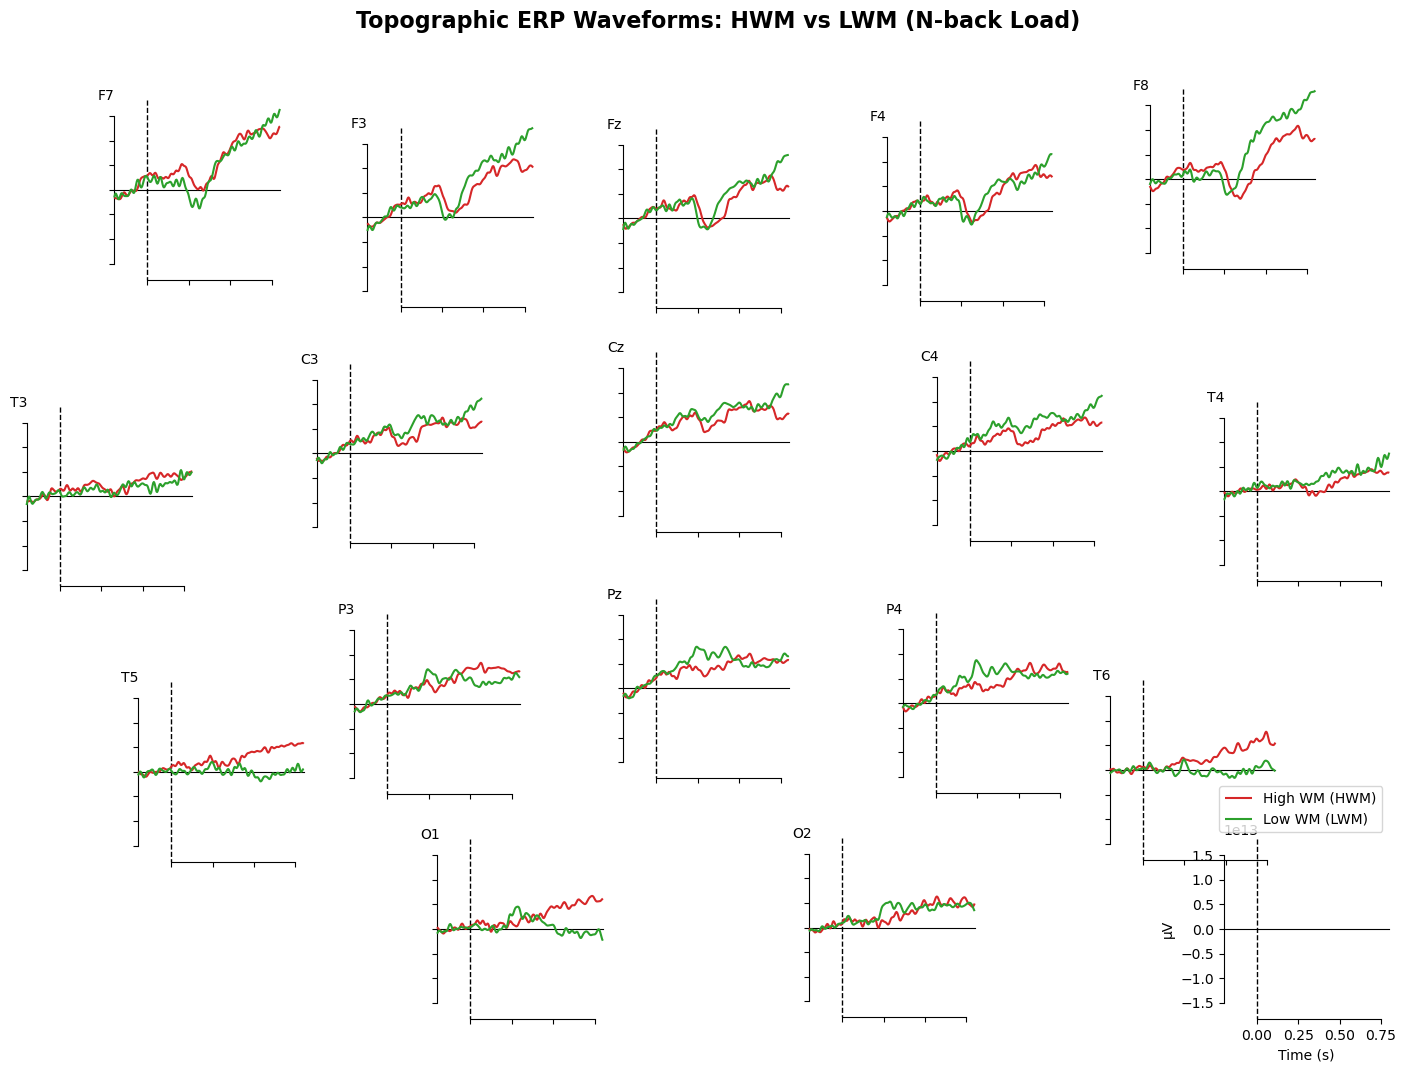

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】路徑與分組配置
# =========================================================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

# 用來收集各組的 Evoked 物件列表
hwm_evokeds = []
lwm_evokeds = []

# =========================================================================
# 【步驟 2】BrainVision 預處理管線 (修正版：收集全通道 + 座標微調)
# =========================================================================
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 找不到任何 .vhdr 檔案，請檢查路徑：{data_dir}")

print(f"🔍 偵測到 {len(file_list)} 個 BrainVision 檔案，啟動全通道 Topo 管線...\n")

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'HWM'
    elif sub_str in lwm_subs:
        group_label = 'LWM'
    else:
        continue  # 排除中間 40% 的受試者
        
    print(f"🧠 正在預處理: {sub_str} ({group_label})")
    
    try:
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        
        # 💡【破案核心修改 1】：讀取標準座標，並手動拉開 Fp1 / Fp2 距離，防止 Topo 繪圖重疊報錯
        montage = mne.channels.make_standard_montage('standard_1020')
        ch_pos = montage.get_positions()['ch_pos']
        
        # 檢查大寫 Fp1/Fp2 或小寫 Fp1/Fp2
        for fp_name, shift in [('Fp1', -0.01), ('Fp2', 0.01), ('FP1', -0.01), ('FP2', 0.01)]:
            if fp_name in ch_pos:
                ch_pos[fp_name][0] += shift  # 微調 X 軸位置 (單位：公尺)
                
        montage_fixed = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='head')
        raw.set_montage(montage_fixed, on_missing='ignore', verbose=False)
        
        # 執行濾波
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)

        # 尋找並讀取同資料夾下的 _events.tsv 檔案
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        if not os.path.exists(tsv_path):
            dir_name = os.path.dirname(file_path)
            tsv_files = glob.glob(os.path.join(dir_name, "*.tsv"))
            if tsv_files: tsv_path = tsv_files[0]

        if not os.path.exists(tsv_path):
            continue
            
        df_events = pd.read_csv(tsv_path, sep='\t')
        target_events_list = []
        nback_mapping = {'1-back': 1, '2-back': 2, '3-back': 3, '4-back': 4}
        sfreq = raw.info['sfreq']
        
        for _, row in df_events.iterrows():
            onset_sec = float(row['onset'])
            trial_type = str(row['trial_type']).strip()
            if trial_type in nback_mapping:
                sample_idx = int(np.round(onset_sec * sfreq))
                target_events_list.append([sample_idx, 0, nback_mapping[trial_type]])
                
        if not target_events_list:
            continue
            
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        # 切出所有 N-back 刺激的 Epochs (保留全通道)
        epochs = mne.Epochs(
            raw, events, event_id=None, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        if len(epochs) == 0:
            continue
            
        # 💡【破案核心修改 2】：移除 average 裡的 verbose=False
        evoked = epochs.average()
        
        # 💡【破案核心修改 3】：改用直接相乘放大，取代舊版 MNE 沒有的 apply_scale
        evoked.data = evoked.data * 1e6  # 轉微伏 (uV)
        
        # 依組別歸類
        if group_label == 'HWM':
            hwm_evokeds.append(evoked)
        else:
            lwm_evokeds.append(evoked)
                
    except Exception as e:
        print(f"❌ 處理 {sub_str} 時發生非預期錯誤: {e}")

# =========================================================================
# # =========================================================================
# 【步驟 3】🎨 繪製全通道 Topography ERP 比較圖 (終極保險移除 Fp1/Fp2 版)
# =========================================================================
print(f"\n✅ 數據收集完成！HWM 組: {len(hwm_evokeds)} 人, LWM 組: {len(lwm_evokeds)} 人")

if not hwm_evokeds or not lwm_evokeds:
    print("❌ 其中一組沒有成功收集到數據，無法繪圖。")
else:
    print("🎨 正在生成 Topographic ERP Waveforms... (正在繪製頭皮分佈圖)")
    
    # 1. 計算兩組的 Grand Average (群體總平均)
    grand_avg_hwm = mne.grand_average(hwm_evokeds, interpolate_bads=True)
    grand_avg_lwm = mne.grand_average(lwm_evokeds, interpolate_bads=True)
    
    # 💡【破案核心關鍵】：直接拔掉會導致重疊報錯的 Fp1 和 Fp2 通道！
    # 這樣 MNE 就不會去計算這兩個點的 2D 投影，直接繞過錯誤
    ch_to_drop = [ch for ch in grand_avg_hwm.ch_names if ch.upper() in ['FP1', 'FP2']]
    if ch_to_drop:
        print(f"🧹 安全移除可能導致投影重疊的邊緣通道: {ch_to_drop}")
        grand_avg_hwm.drop_channels(ch_to_drop)
        grand_avg_lwm.drop_channels(ch_to_drop)
    
    # 2. 建立對應字典與色彩配置
    evokeds_dict = {
        'High WM (HWM)': grand_avg_hwm,
        'Low WM (LWM)': grand_avg_lwm
    }
    colors = {'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'}
    
   # 3. 呼叫 MNE 地形圖排列繪圖
    fig_list = mne.viz.plot_compare_evokeds(
        evokeds_dict,
        axes='topo',             # 依照頭皮物理位置排列
        colors=colors,
        linestyles={'High WM (HWM)': '-', 'Low WM (LWM)': '-'},
        show=False
    )
    
    # 💡【關鍵破案點】：舊版 MNE 在 topo 模式下回傳的是 list，我們要取出第一個元素(Figure)
    if isinstance(fig_list, list):
        main_fig = fig_list[0]
    else:
        main_fig = fig_list

    # 4. 現在可以安全地調整大小、加標題與存檔了！
    main_fig.set_size_inches(15, 11)
    main_fig.suptitle("Topographic ERP Waveforms: HWM vs LWM (N-back Load)", fontsize=16, fontweight='bold', y=0.96)
    
    # 儲存圖片
    output_png = 'erp_topography_compare.png'
    main_fig.savefig(output_png, dpi=300, bbox_inches='tight')
    print(f"💾 【大功告成】全通道地形波形圖已成功儲存為: {output_png}")
    
    plt.show()